# Import libraries

In [49]:
# Import nessessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as scipy
import calendar
from scipy import stats

# seaborn is a data visualization library built on matplotlib
import seaborn as sns

## Load the data

In [50]:
edgap = pd.read_excel("/Users/jisoo/Desktop/MSDS/26_Fall/DATA5100/education/data/EdGap_data.xlsx", dtype={'NCESSCH School ID':object})
school_information = pd.read_csv("/Users/jisoo/Desktop/MSDS/26_Fall/DATA5100/education/data/ccd_sch_029_1617_w_1a_11212017.csv", encoding="latin1")

/opt/miniconda3/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


# Explore the contents of the data sets

In [51]:
edgap.head()

,NCESSCH School ID,CT Unemployment Rate,CT Pct Adults with College Degree,CT Pct Childre In Married Couple Family,CT Median Household Income,School ACT average (or equivalent if SAT score),School Pct Free and Reduced Lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641


In [52]:
school_information.head()

,SCHOOL_YEAR,STATENAME,ST,SCH_NAME,LEA_NAME,ST_LEAID,LEAID,ST_SCHID,NCESSCH,SCHID,...,MZIP,LSTREET1,LCITY,LSTATE,LZIP,UPDATED_STATUS_TEXT,EFFECTIVE_DATE,SCH_TYPE_TEXT,SCH_TYPE,LEVEL
0,2016-2017,ALABAMA,AL,Sequoyah Sch - Chalkville Campus,Alabama Youth Services,AL-210,100002,AL-210-0020,1.000020e+10,100277,...,35220,1000 Industrial School Road,Birmingham,AL,35220,Open,3/3/10,Alternative School,4,High
1,2016-2017,ALABAMA,AL,Camps,Alabama Youth Services,AL-210,100002,AL-210-0050,1.000020e+10,101667,...,36057,1601 County Rd. 57,Prattville,AL,36067,Open,3/3/10,Alternative School,4,High
2,2016-2017,ALABAMA,AL,Det Ctr,Alabama Youth Services,AL-210,100002,AL-210-0060,1.000020e+10,101670,...,36057,2109 Bashi Rd Bldg 509,Thomasville,AL,36784,Open,3/3/10,Alternative School,4,High
3,2016-2017,ALABAMA,AL,Wallace Sch - Mt Meigs Campus,Alabama Youth Services,AL-210,100002,AL-210-0030,1.000020e+10,101705,...,36057,1000 Industrial School Road,Mount Meigs,AL,36057,Open,3/3/10,Alternative School,4,High
4,2016-2017,ALABAMA,AL,McNeel Sch - Vacca Campus,Alabama Youth Services,AL-210,100002,AL-210-0040,1.000020e+10,101706,...,35206,8950 Roebuck Blvd,Birmingham,AL,35206,Open,3/3/10,Alternative School,4,High


In [53]:
edgap.info()

<class 'pandas.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   NCESSCH School ID                                7986 non-null   object 
 1   CT Unemployment Rate                             7972 non-null   float64
 2   CT Pct Adults with College Degree                7973 non-null   float64
 3   CT Pct Childre In Married Couple Family          7961 non-null   float64
 4   CT Median Household Income                       7966 non-null   float64
 5   School ACT average (or equivalent if SAT score)  7986 non-null   float64
 6   School Pct Free and Reduced Lunch                7986 non-null   float64
dtypes: float64(6), object(1)
memory usage: 436.9+ KB


In [54]:
school_information.info()

<class 'pandas.DataFrame'>
RangeIndex: 102181 entries, 0 to 102180
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   SCHOOL_YEAR          102181 non-null  str    
 1   STATENAME            102181 non-null  str    
 2   ST                   102181 non-null  str    
 3   SCH_NAME             102181 non-null  str    
 4   LEA_NAME             102181 non-null  str    
 5   ST_LEAID             102181 non-null  str    
 6   LEAID                102181 non-null  int64  
 7   ST_SCHID             102181 non-null  str    
 8   NCESSCH              102181 non-null  float64
 9   SCHID                102181 non-null  int64  
 10  MSTREET1             102181 non-null  str    
 11  MCITY                102181 non-null  str    
 12  MSTATE               102181 non-null  str    
 13  MZIP                 102181 non-null  int64  
 14  LSTREET1             102181 non-null  str    
 15  LCITY                102181 

# Plot

To view the relationship between variables, we create a scatter plot

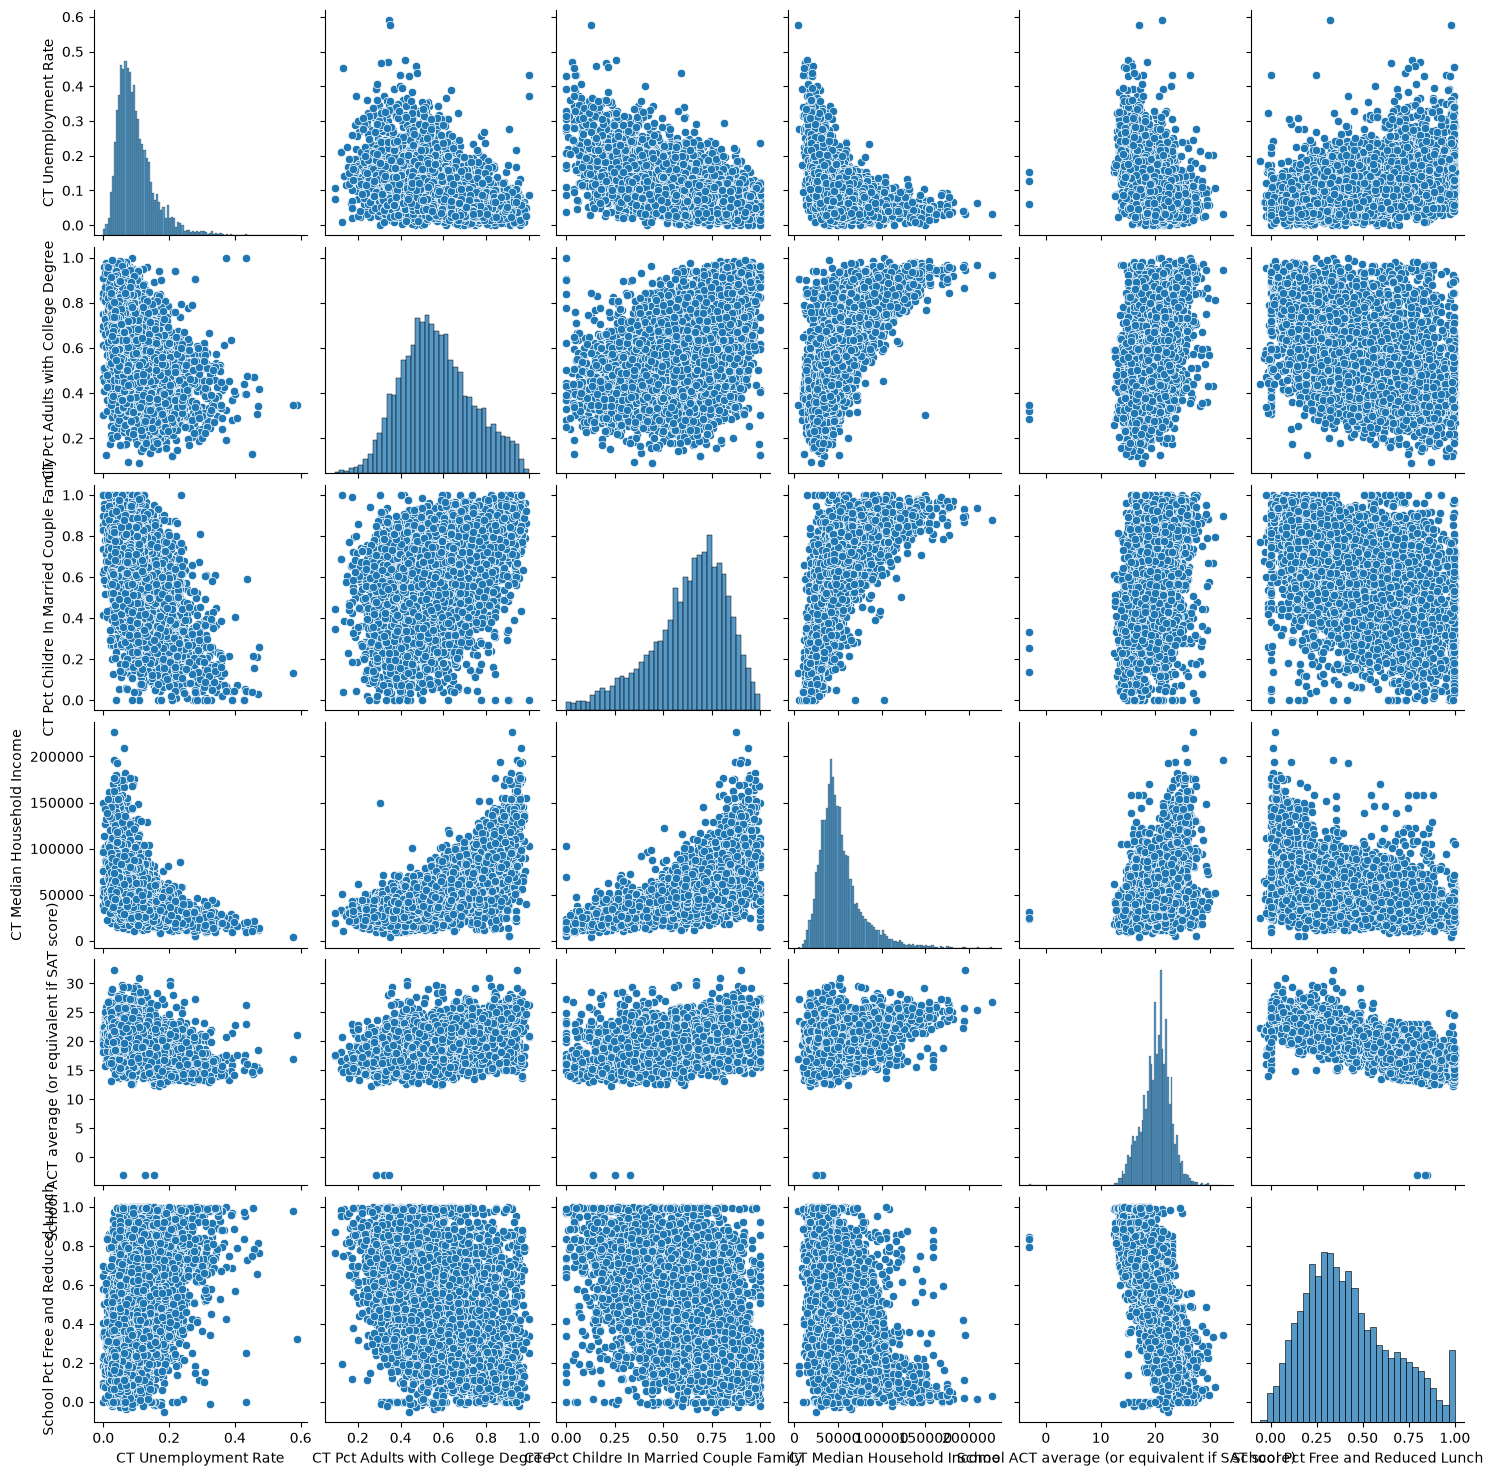

In [55]:
sns.pairplot(edgap.drop(columns="NCESSCH School ID"));
plt.show()

Add regression lines and format the pair plot

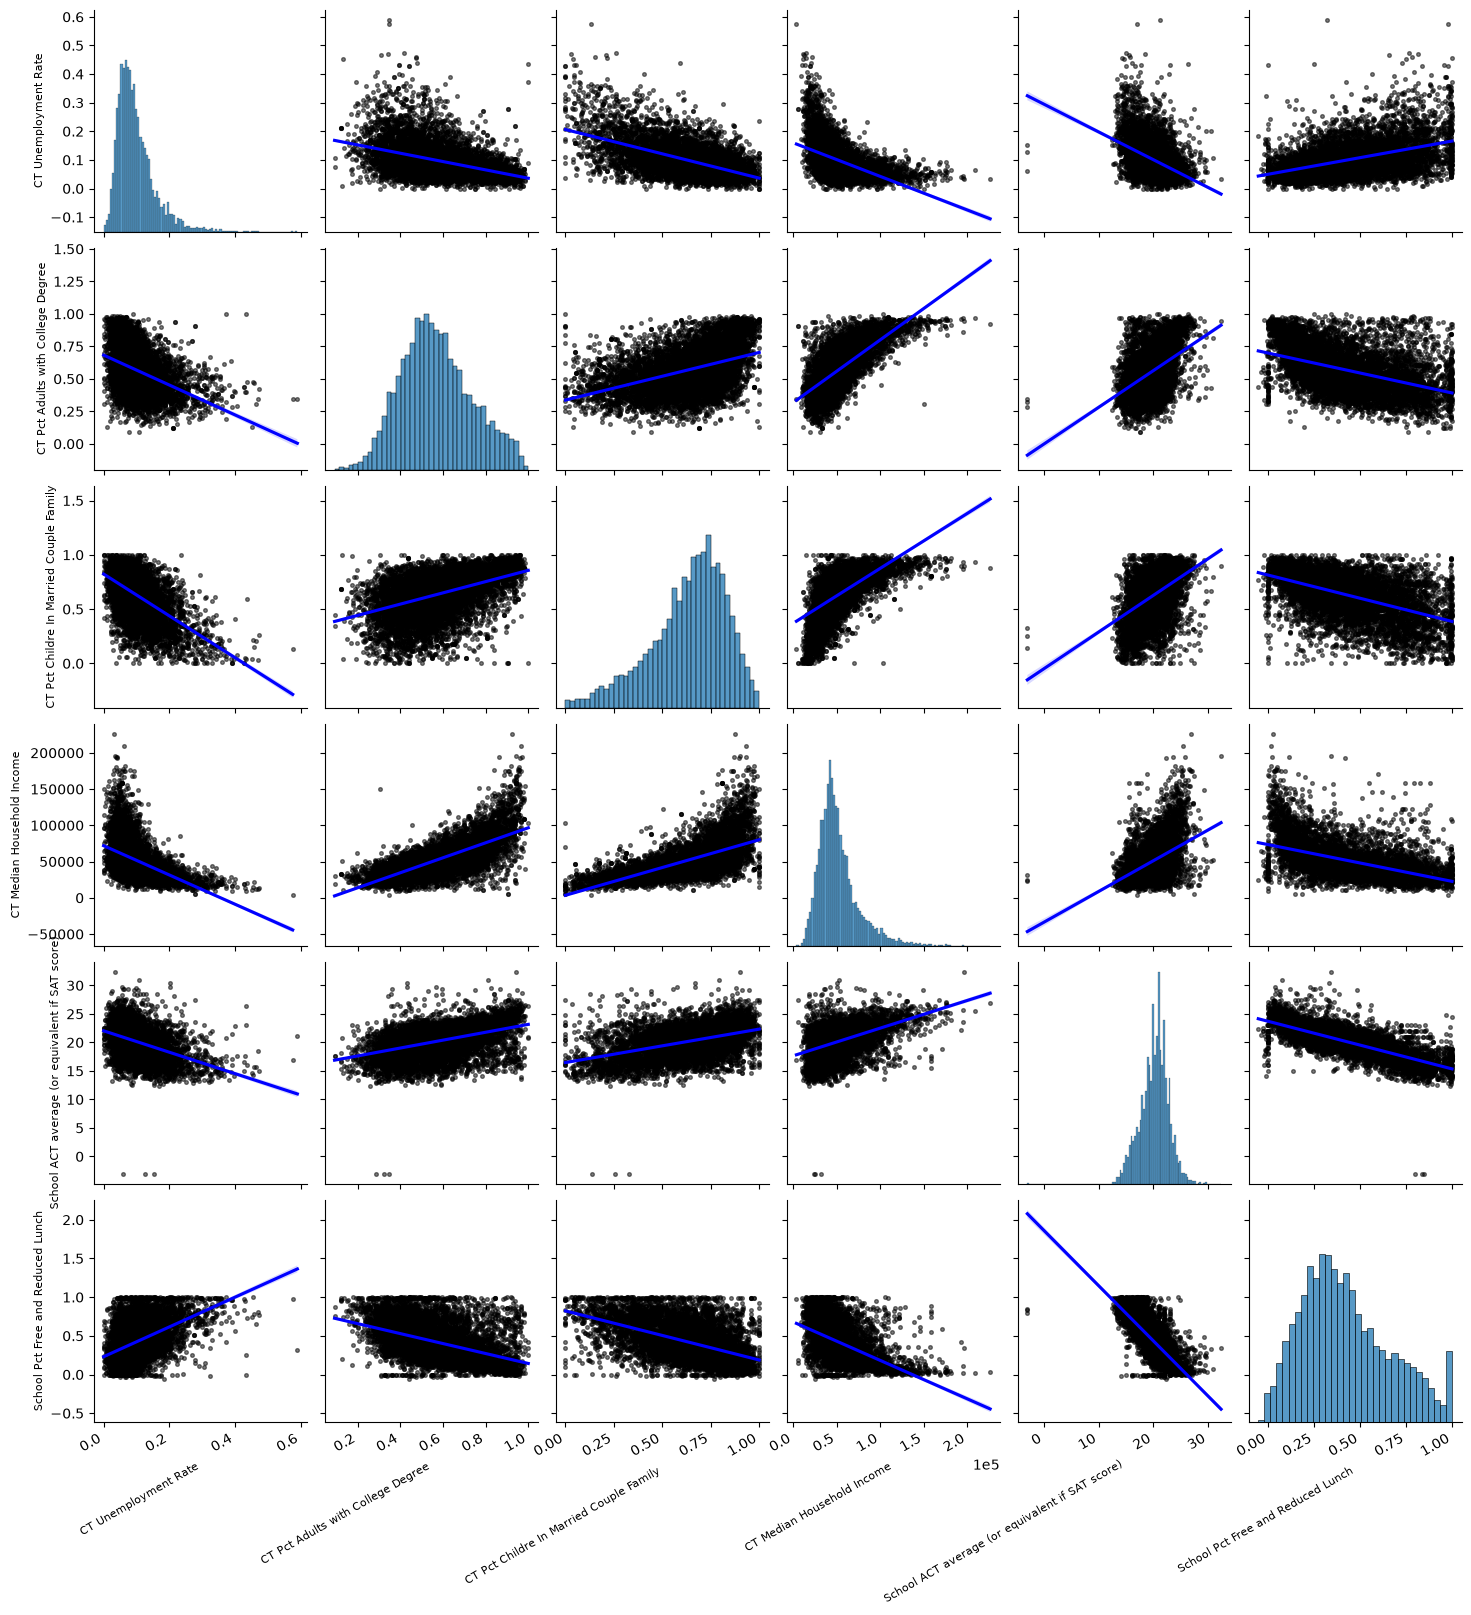

In [56]:
fig = sns.pairplot(
    edgap.drop(columns="NCESSCH School ID"),
    #y_vars = ['School ACT average (or equivalent if SAT score)'], -> to focus on one row
    kind = "reg",
    plot_kws={
        "line_kws":{"color":"blue"},
        "scatter_kws":{"alpha":0.5, "color":"k","s":7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

# Data Preparatoin

In [57]:
edgap = edgap.rename(
    columns = {
       'NCESSCH School ID': 'id', 
       'CT Unemployment Rate': 'rate_unemployment',
       'CT Pct Adults with College Degree': 'percent_college',
       'CT Pct Childre In Married Couple Family': 'percent_married', 
       'CT Median Household Income': 'median_income',
       'School ACT average (or equivalent if SAT score)': 'average_act',
       'School Pct Free and Reduced Lunch': 'percent_lunch',
    }
)

In [58]:
school_information = school_information.rename(
    columns = {
       'NCESSCH': 'id', 
       'SCHOOL_YEAR': 'year',
       'LSTATE': 'state',
       'LZIP': 'zip_code', 
       'SCH_TYPE_TEXT': 'school_type',
       'LEVEL': 'school_level',
       'CHARTER_TEXT': 'charter',
    }
)

### Select relevant subsets of the data

### We can rename, if necessary

# Join dataframe

In [59]:
school_information['id'] = school_information['id'].astype('object')

In [60]:
df = edgap.merge(
    school_information,
    how = 'left', # use the left join
    on = 'id'     # use id as the key
)

# Quality Control

Check the min and max values in each column.

In [61]:
df.describe()

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,LEAID,SCHID,MZIP,zip_code,SCH_TYPE
count,7972.000000,7973.000000,7961.000000,7966.000000,7986.000000,7986.000000,0.0,0.0,0.0,0.0,0.0
mean,0.098730,0.568930,0.633440,52026.905222,20.181532,0.420651,NaN,NaN,NaN,NaN,NaN
std,0.058959,0.165704,0.196764,24228.057079,2.595201,0.239754,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.091493,0.000000,3589.000000,-3.070818,-0.054545,NaN,NaN,NaN,NaN,NaN
25%,0.058655,0.450828,0.523810,36597.250000,18.600000,0.238501,NaN,NaN,NaN,NaN,NaN
50%,0.085649,0.554979,0.667594,46833.500000,20.400000,0.381570,NaN,NaN,NaN,NaN,NaN
75%,0.123376,0.676571,0.777135,61369.250000,21.910867,0.575447,NaN,NaN,NaN,NaN,NaN
max,0.590278,1.000000,1.000000,226181.000000,32.362637,0.998729,NaN,NaN,NaN,NaN,NaN


Set out of range values to NaN using np.nan

In [62]:
df.loc[df['percent_lunch'] < 0, 'percent_lunch'] = np.nan
df.loc[df['average_act'] < 1, 'average_act'] = np.nan

Check the types, levels, and charter status of schools

In [63]:
df['school_type'].value_counts()

Series([], Name: count, dtype: int64)